
# Batched lens models with BlackJAX + ChainConsumer

This notebook shows how to:
- Simulate a mock strong-lens image with `jax_lens`.
- Evaluate *multiple* lens mass models (SIS, SIE, NFW) in a batched way.
- Run BlackJAX NUTS for each model.
- Visualize posteriors with ChainConsumer.

Notes:
- We keep everything on CPU (`JAX_PLATFORM_NAME=cpu`) and use float64.
- Different mass models have different parameterizations. We use a single padded unconstrained vector so we can `vmap` log-posteriors across models.


In [1]:

# Environment + imports
import os
# os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")  # avoid CUDA plugin warnings

import sys
sys.path.insert(0, "..")  # for local jax_lens

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.nn as jnn
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import blackjax
from blackjax.adaptation.window_adaptation import window_adaptation
from chainconsumer import ChainConsumer

from jax_lens.lens.tracer import simple_tracer_image
from jax_lens.fitting.imaging import convolve_image
from jax_lens.pipeline import create_simple_lens_likelihood

jax.config.update("jax_enable_x64", True)
plt.rcParams["figure.figsize"] = (12, 4)

MODEL_NAMES = ["SIS", "SIE", "NFW"]


In [2]:

# Utilities: grid/PSF + transforms + parameter packing/unpacking

def create_grid(n_pixels: int, pixel_scale: float) -> jnp.ndarray:
    coords = jnp.linspace(-(n_pixels - 1) / 2 * pixel_scale, (n_pixels - 1) / 2 * pixel_scale, n_pixels)
    yy, xx = jnp.meshgrid(coords, coords, indexing="ij")
    return jnp.stack([yy, xx], axis=-1)

def create_psf(size: int = 13, sigma: float = 1.5) -> jnp.ndarray:
    half = (size - 1) / 2
    coords = jnp.linspace(-half, half, size)
    yy, xx = jnp.meshgrid(coords, coords, indexing="ij")
    psf = jnp.exp(-0.5 * (yy**2 + xx**2) / sigma**2)
    return psf / psf.sum()

def wrap_angle(phi: jnp.ndarray) -> jnp.ndarray:
    return (phi + jnp.pi) % (2 * jnp.pi) - jnp.pi

def softplus_pos(raw: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    return floor + jnn.softplus(raw)

def inv_softplus_pos(val: jnp.ndarray, floor: float = 1e-3) -> jnp.ndarray:
    return jnp.log(jnp.expm1(jnp.maximum(val - floor, 1e-8)))

def bounded_from_raw(raw: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    return low + (high - low) * jnn.sigmoid(raw)

def raw_from_bounded(val: jnp.ndarray, low: float, high: float) -> jnp.ndarray:
    y = jnp.clip((val - low) / (high - low), 1e-6, 1 - 1e-6)
    return jnp.log(y) - jnp.log1p(-y)

# We use a 13-dim unconstrained theta:
#   [0:6]  mass block (centre_y, centre_x, p1, p2, p3, p4)
#   [6:13] source block (centre_y, centre_x, intensity, r_eff, n, axis_ratio, angle)
# Branch logic inside decoders interprets p1..p4 per model.

# --- Mass decoders/encoders ---

def mass_params_from_raw(model_id: int, raw: jnp.ndarray) -> dict:
    cy, cx, p1, p2, p3, p4 = raw
    centre = jnp.array([cy, cx])
    if model_id == 0:  # SIS
        return {"centre": centre, "einstein_radius": softplus_pos(p1, 0.01)}
    elif model_id == 1:  # SIE
        return {
            "centre": centre,
            "einstein_radius": softplus_pos(p1, 0.01),
            "axis_ratio": bounded_from_raw(p2, 0.05, 0.99),
            "angle": wrap_angle(p3),
        }
    else:  # NFW
        return {
            "centre": centre,
            "kappa_s": softplus_pos(p1, 1e-3),
            "scale_radius": softplus_pos(p2, 1e-3),
            "axis_ratio": bounded_from_raw(p3, 0.2, 0.99),
            "angle": wrap_angle(p4),
        }


def mass_raw_from_params(model_id: int, params: dict) -> jnp.ndarray:
    cy, cx = params["centre"]
    if model_id == 0:
        p1 = inv_softplus_pos(params["einstein_radius"], 0.01)
        return jnp.array([cy, cx, p1, 0.0, 0.0, 0.0])
    elif model_id == 1:
        p1 = inv_softplus_pos(params["einstein_radius"], 0.01)
        p2 = raw_from_bounded(params["axis_ratio"], 0.05, 0.99)
        p3 = params["angle"]
        return jnp.array([cy, cx, p1, p2, p3, 0.0])
    else:
        p1 = inv_softplus_pos(params["kappa_s"], 1e-3)
        p2 = inv_softplus_pos(params["scale_radius"], 1e-3)
        p3 = raw_from_bounded(params["axis_ratio"], 0.2, 0.99)
        p4 = params["angle"]
        return jnp.array([cy, cx, p1, p2, p3, p4])

# --- Source decoders/encoders ---

def source_params_from_raw(raw: jnp.ndarray) -> dict:
    cy, cx, inten, r_eff, n_ser, q_raw, ang = raw
    return {
        "centre": jnp.array([cy, cx]),
        "intensity": softplus_pos(inten, 1e-3),
        "effective_radius": softplus_pos(r_eff, 1e-3),
        "sersic_index": softplus_pos(n_ser, 0.2),
        "axis_ratio": bounded_from_raw(q_raw, 0.2, 0.99),
        "angle": wrap_angle(ang),
    }


def source_raw_from_params(params: dict) -> jnp.ndarray:
    cy, cx = params["centre"]
    inten = inv_softplus_pos(params["intensity"], 1e-3)
    r_eff = inv_softplus_pos(params["effective_radius"], 1e-3)
    n_ser = inv_softplus_pos(params["sersic_index"], 0.2)
    q_raw = raw_from_bounded(params["axis_ratio"], 0.2, 0.99)
    ang = params["angle"]
    return jnp.array([cy, cx, inten, r_eff, n_ser, q_raw, ang])

# --- Whole-theta helpers ---

def unpack_theta(theta: jnp.ndarray, model_id: int) -> dict:
    mass_raw = theta[:6]
    src_raw = theta[6:]
    return {
        "lens_mass": mass_params_from_raw(model_id, mass_raw),
        "source_light": source_params_from_raw(src_raw),
    }


def pack_theta(params: dict, model_id: int) -> jnp.ndarray:
    mass_raw = mass_raw_from_params(model_id, params["lens_mass"])
    src_raw = source_raw_from_params(params["source_light"])
    return jnp.concatenate([mass_raw, src_raw])


W0112 14:14:22.815222   52732 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0112 14:14:22.819590   52627 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


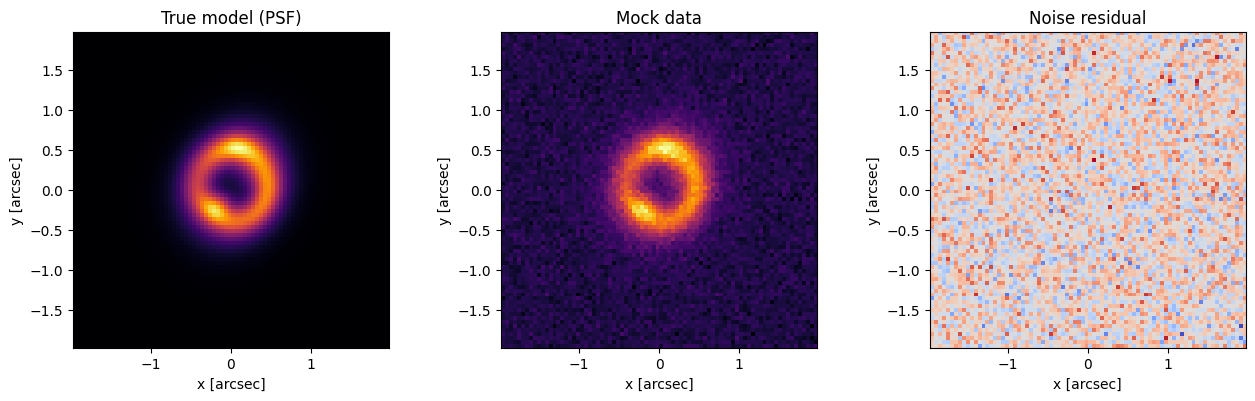

In [3]:

# Simulate mock data (true model = SIE)

n_pixels = 80
pixel_scale = 0.05
grid = create_grid(n_pixels, pixel_scale)
grid_flat = grid.reshape(-1, 2)
psf = create_psf(size=13, sigma=1.5)

true_model_id = 1  # SIE
true_params = {
    "lens_mass": {
        "centre": jnp.array([0.0, 0.0]),
        "einstein_radius": 1.05,
        "axis_ratio": 0.82,
        "angle": 0.5,
    },
    "source_light": {
        "centre": jnp.array([0.08, 0.04]),
        "intensity": 1.2,
        "effective_radius": 0.3,
        "sersic_index": 1.2,
        "axis_ratio": 0.7,
        "angle": 1.0,
    },
}

theta_true = pack_theta(true_params, true_model_id)

true_image = simple_tracer_image(
    grid=grid_flat,
    lens_mass_params=true_params["lens_mass"],
    source_light_params=true_params["source_light"],
    lens_mass_type="sie",
    source_light_type="sersic",
).reshape(n_pixels, n_pixels)
true_image = convolve_image(true_image, psf, padding="edge")

noise_sigma = 0.2
noise_map = jnp.ones_like(true_image) * noise_sigma
rng = np.random.default_rng(0)
data = jnp.array(np.array(true_image) + rng.normal(0.0, noise_sigma, true_image.shape))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
extent = (
    -(n_pixels - 1) / 2 * pixel_scale,
    (n_pixels - 1) / 2 * pixel_scale,
    -(n_pixels - 1) / 2 * pixel_scale,
    (n_pixels - 1) / 2 * pixel_scale,
)
axes[0].imshow(np.array(true_image), origin="lower", extent=extent, cmap="inferno")
axes[0].set_title("True model (PSF)")
axes[1].imshow(np.array(data), origin="lower", extent=extent, cmap="inferno")
axes[1].set_title("Mock data")
axes[2].imshow(np.array(data - true_image), origin="lower", extent=extent, cmap="coolwarm")
axes[2].set_title("Noise residual")
for ax in axes:
    ax.set_xlabel("x [arcsec]")
    ax.set_ylabel("y [arcsec]")
plt.tight_layout()


In [4]:

# Build per-model likelihoods (static config per mass model)

likelihood_fns = []
for name in MODEL_NAMES:
    likelihood_fns.append(
        create_simple_lens_likelihood(
            grid=grid_flat,
            data=data.flatten(),
            noise_map=noise_map.flatten(),
            z_lens=0.5,
            z_source=1.0,
            lens_mass_type=name.lower(),
            source_light_type="sersic",
            psf=psf,
            image_shape=(n_pixels, n_pixels),
        )
    )

likelihood_fns = [jax.jit(fn) for fn in likelihood_fns]

# Simple Gaussian prior in raw (unconstrained) space
prior_loc = theta_true  # centre prior at true SIE params for all models
prior_scale = jnp.ones_like(theta_true) * 0.5

@jax.jit
def log_prior(theta: jnp.ndarray) -> jnp.ndarray:
    z = (theta - prior_loc) / prior_scale
    return -0.5 * jnp.sum(z**2) - jnp.sum(jnp.log(prior_scale * jnp.sqrt(2 * jnp.pi)))

# Log-posterior for a given model id

def log_posterior_fn(model_id: int):
    like = likelihood_fns[model_id]
    def _logpost(theta: jnp.ndarray) -> jnp.ndarray:
        params = unpack_theta(theta, model_id)
        return like(params) + log_prior(theta)
    return jax.jit(_logpost)

logpost_sis = log_posterior_fn(0)
logpost_sie = log_posterior_fn(1)
logpost_nfw = log_posterior_fn(2)
logpost_list = [logpost_sis, logpost_sie, logpost_nfw]

# Batched log-posterior evaluation across models (vmap over model_id + theta)

def logpost_switch(model_id, theta):
    return lax.switch(model_id, logpost_list, theta)

batched_logpost = jax.jit(jax.vmap(logpost_switch, in_axes=(0, 0)))

model_ids = jnp.array([0, 1, 2])
init_thetas = jnp.stack([
    theta_true + 0.1 * jnp.ones_like(theta_true),  # SIS initial guess
    theta_true,                                    # SIE near truth
    theta_true + 0.1 * jnp.ones_like(theta_true),  # NFW initial guess
], axis=0)

print("Batched log-posteriors:", batched_logpost(model_ids, init_thetas))


Batched log-posteriors: [-20915.81703908   1243.82799014 -68901.71191079]


In [5]:

# Run NUTS for each model (sequentially, but using the shared padded theta)

rng = jr.PRNGKey(123)
results = {}

num_adapt = 400
num_samples = 600
burn_in = 200

for model_id, name in enumerate(MODEL_NAMES):
    rng, rng_init, rng_adapt, rng_sample = jr.split(rng, 4)
    theta_init = theta_true + 0.1 * jr.normal(rng_init, theta_true.shape)

    logpost = logpost_list[model_id]

    adapt = window_adaptation(
        blackjax.nuts,
        logpost,
        initial_step_size=0.02,
        target_acceptance_rate=0.8,
        is_mass_matrix_diagonal=True,
    )
    adapt_results, _ = adapt.run(rng_adapt, theta_init, num_steps=num_adapt)

    nuts = blackjax.nuts.differentiable(logpost, **adapt_results.parameters)

    @jax.jit
    def one_step(state, key):
        new_state, info = nuts.step(key, state)
        return new_state, (new_state, info)

    keys = jr.split(rng_sample, num_samples)
    final_state, (states, infos) = jax.lax.scan(one_step, adapt_results.state, keys)

    samples = states.position[burn_in:]
    results[name] = {
        "samples_raw": samples,
        "final_state": final_state,
    }
    print(f"{name}: collected {samples.shape[0]} samples after burn-in")


SIS: collected 400 samples after burn-in
SIE: collected 400 samples after burn-in
NFW: collected 400 samples after burn-in


In [6]:

# Convert samples to physical parameters for plotting

PARAM_ORDER = [
    "mass_scale",      # Einstein radius or kappa_s
    "mass_axis_ratio", # 1.0 for SIS
    "source_y",
    "source_x",
    "r_eff",
    "sersic_n",
    "source_axis_ratio",
]


def flatten_phys(theta: jnp.ndarray, model_id: int) -> jnp.ndarray:
    params = unpack_theta(theta, model_id)
    mass = params["lens_mass"]
    if model_id == 0:  # SIS
        mass_scale = mass["einstein_radius"]
        mass_q = 1.0
    elif model_id == 1:  # SIE
        mass_scale = mass["einstein_radius"]
        mass_q = mass["axis_ratio"]
    else:  # NFW
        mass_scale = mass["kappa_s"]
        mass_q = mass.get("axis_ratio", 1.0)

    src = params["source_light"]
    return jnp.array([
        mass_scale,
        mass_q,
        src["centre"][0],
        src["centre"][1],
        src["effective_radius"],
        src["sersic_index"],
        src["axis_ratio"],
    ])

phys_samples = {}
for model_id, name in enumerate(MODEL_NAMES):
    raw = results[name]["samples_raw"]
    phys = jax.vmap(lambda th: flatten_phys(th, model_id))(raw)
    phys_samples[name] = np.array(phys)
    print(name, phys_samples[name].shape)


SIS (400, 7)
SIE (400, 7)
NFW (400, 7)


Parameter mass_scale in chain SIS is not constrained
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


IndexError: index 0 is out of bounds for axis 0 with size 0

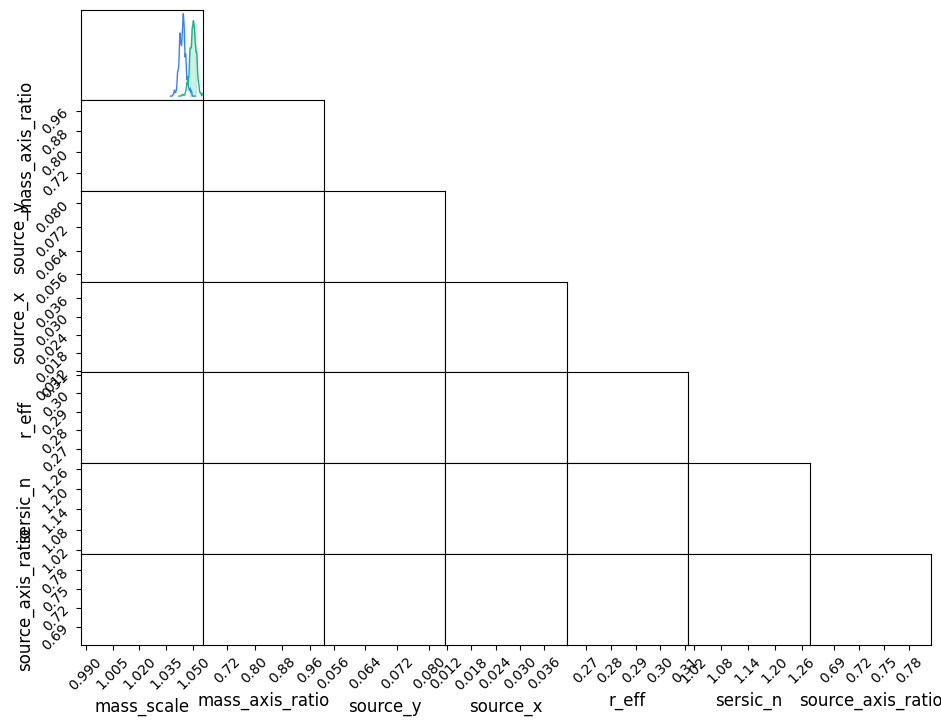

In [24]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain

chains = {}
for name in MODEL_NAMES:
  df = pd.DataFrame(phys_samples[name], columns=PARAM_ORDER)
  chains[name] = Chain(samples=df, name=name)

c = ChainConsumer()
for chain in chains.values():
  c.add_chain(chain)

fig = c.plotter.plot(figsize=(10, 8))
plt.show()

/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264: UserWarning: Only 400 samples available to compute an HDI for column 'source_y' in chain 'SIS (source)'. Results may be unreliable; consider enabling KDE or providing more samples.
  return callback(chain, column)
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264: UserWarning: Only 400 samples available to compute an HDI for column 'source_y' in chain 'SIE (source)'. Results may be unreliable; consider enabling KDE or providing more samples.
  return callback(chain, column)
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264:

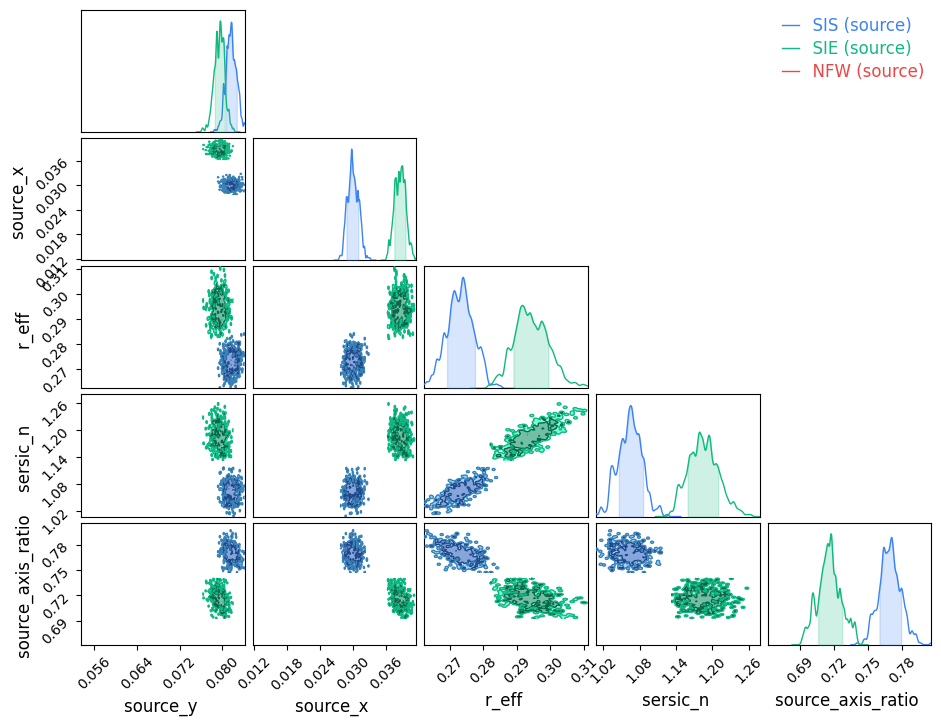

/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264: UserWarning: Only 400 samples available to compute an HDI for column 'einstein_radius' in chain 'SIS (mass)'. Results may be unreliable; consider enabling KDE or providing more samples.
  return callback(chain, column)
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264: UserWarning: Only 400 samples available to compute an HDI for column 'einstein_radius' in chain 'SIE (mass)'. Results may be unreliable; consider enabling KDE or providing more samples.
  return callback(chain, column)
/home/nataliehogg/Documents/Codes/myenvs/EverythingDev/venv/lib/python3.12/site-packages/chainconsumer/analysis.py:264: UserWarning: Only 400 samples available to compute an HDI for column 'axis_ratio' in chain 'SIE (mass)'. Results may be unreliable; consider enabling KDE or providing more samples.
  return callback(cha

ValueError: Axis limits cannot be NaN or Inf

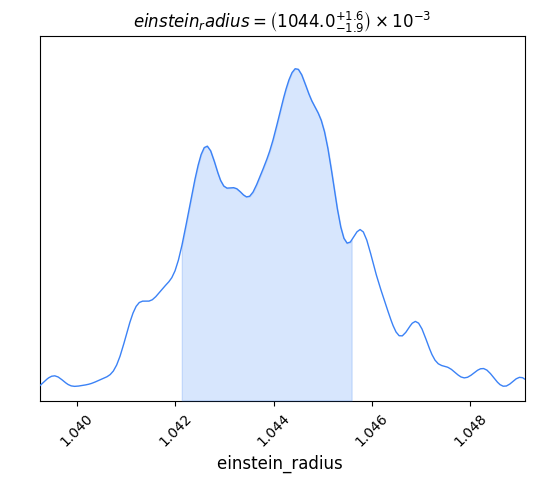

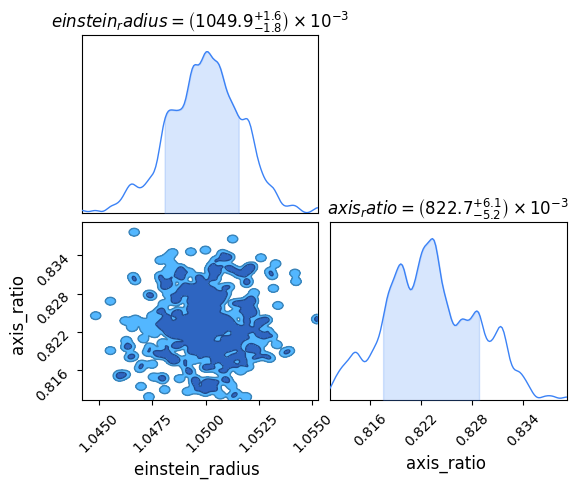

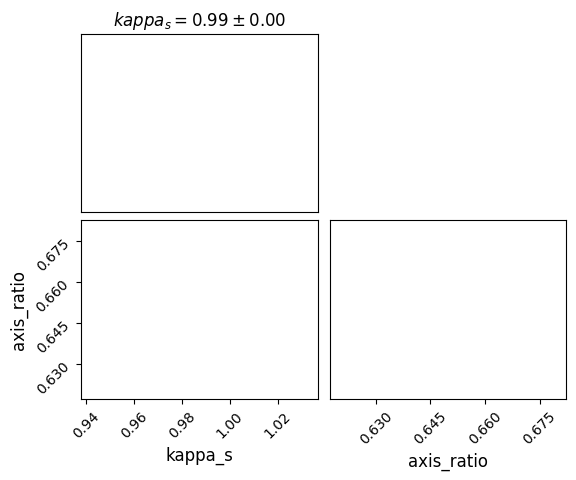

In [23]:
import pandas as pd
from chainconsumer import ChainConsumer, Chain
from chainconsumer.statistics  import SummaryStatistic

# Source-only chains (shared across models)
source_cols = ["source_y", "source_x", "r_eff", "sersic_n", "source_axis_ratio"]
source_chains = {}
for name in MODEL_NAMES:
  phys = phys_samples[name]
  df = pd.DataFrame({
      "source_y": phys[:, 2],
      "source_x": phys[:, 3],
      "r_eff": phys[:, 4],
      "sersic_n": phys[:, 5],
      "source_axis_ratio": phys[:, 6],
  })
  source_chains[name] = Chain(samples=df, name=f"{name} (source)", statistics=SummaryStatistic.HDI)

c = ChainConsumer()
for ch in source_chains.values():
  c.add_chain(ch)
fig = c.plotter.plot(columns=source_cols, figsize=(10, 8))
plt.show()

# Mass-only plots per model (avoid mixing incompatible parameters)
mass_figs = []
for name in MODEL_NAMES:
  phys = phys_samples[name]
  if name == "SIS":
      df = pd.DataFrame({"einstein_radius": phys[:, 0]})
  elif name == "SIE":
      df = pd.DataFrame({
          "einstein_radius": phys[:, 0],
          "axis_ratio": phys[:, 1],
      })
  else:  # NFW
      df = pd.DataFrame({
          "kappa_s": phys[:, 0],
          "axis_ratio": phys[:, 1],
      })
  chain = Chain(samples=df, name=f"{name} (mass)", statistics=SummaryStatistic.HDI)
  c_mass = ChainConsumer()
  c_mass.add_chain(chain)
  mass_figs.append(c_mass.plotter.plot(figsize=(6, 5)))

for fig in mass_figs:
  plt.show()
